# Data Cleaning and Feature Engineering
Dataset: `Customer_Data.csv`
This notebook processes the dataset, handling missing values and preparing features for machine learning.

## Part 1: Handling Missing Values
### 1. Data Loading and Missing Value Audit

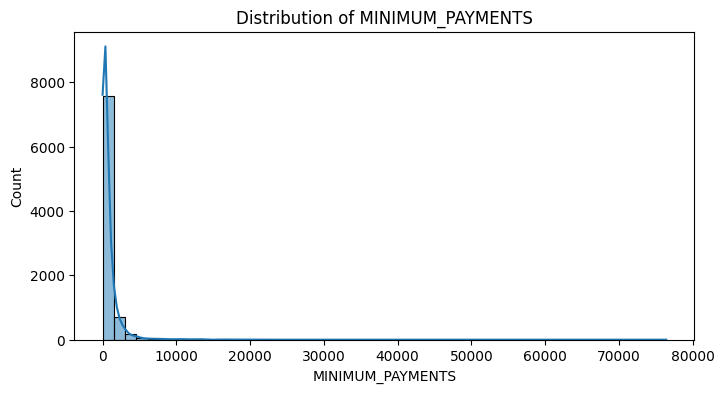

Imputed MINIMUM_PAYMENTS with median.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('Customer_Data.csv')

# Calculate missing values and percentages
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Combine into a DataFrame for readability
missing_audit = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_percentages
})

# Show columns that actually have missing data
missing_cols = missing_audit[missing_audit['Missing_Count'] > 0].sort_values(by='Percentage', ascending=False)
print("Columns with missing values:")
print(missing_cols)

### 2. Imputation for Highly Skewed Data (`MINIMUM_PAYMENTS`)
Since `MINIMUM_PAYMENTS` has ~3.5% missing values, we can impute it. Financial data is often heavily skewed, so median imputation is safer than mean imputation.

In [9]:
# Plotting distribution of MINIMUM_PAYMENTS
plt.figure(figsize=(8, 4))
sns.histplot(df['MINIMUM_PAYMENTS'].dropna(), bins=50, kde=True)
plt.title('Distribution of MINIMUM_PAYMENTS')
plt.show()

# Fill missing values with median
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
print("Imputed MINIMUM_PAYMENTS with median.")

New shape after dropping missing CREDIT_LIMIT rows: (8636, 18)


### 3. Row-wise Deletion (`CREDIT_LIMIT`)
The `CREDIT_LIMIT` column is only missing 1 value (0.01%). Imputing a single value out of 8950 rows is unnecessary, so we can simply drop this row.

In [10]:
# Drop rows where CREDIT_LIMIT is missing
df = df.dropna(subset=['CREDIT_LIMIT'])
print(f"New shape after dropping missing CREDIT_LIMIT rows: {df.shape}")

Sanity check passed: No missing values remain.


### 4. Final Sanity Check for Missing Values

In [11]:
# Assert statement to ensure no missing values remain
assert df.isnull().sum().sum() == 0, "Error: There are still missing values in the DataFrame!"
print("Sanity check passed: No missing values remain.")

Dropped CUSTID column.


## Part 2: Feature Selection and Categorical Data
### 5. Dropping Identifiers
The dataset contains only numerical features, aside from `CUSTID`. Since `CUSTID` is a unique identifier, it provides no predictive power and should be removed before modeling.

In [12]:
if 'CUSTID' in df.columns:
    df = df.drop(columns=['CUSTID'])
    print("Dropped CUSTID column.")

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


### 6. Final Dataset Compilation

In [13]:
# Display datatypes to ensure they are all numerical
print(df.dtypes)

# Display the first 5 rows of the model-ready dataset
df.head()

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12
